### Check the quality of Healthy-Aging_KG and Compare to AD-KG

In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from collections import defaultdict
import seaborn as sns

In [2]:
health_kg_path = "../Anyburl/data/KG/healthy_aging_kg.pkl"
ad_kg_path = "../Anyburl/data/KG/ad_noreverse_causal.pkl"

def load_graph(kg_path):
    with open(kg_path, 'rb') as f:
        kg = pickle.load(f)
    print(f"Graph has {kg.number_of_nodes()} nodes and {kg.number_of_edges()} edges.")
    return kg

health_kg = load_graph(health_kg_path)
ad_kg = load_graph(ad_kg_path)

Graph has 4338 nodes and 7410 edges.
Graph has 3732 nodes and 5277 edges.


In [162]:
ad_edges_to_remove = []
for src, dst, rel, attr in ad_kg.edges(data=True, keys=True):
    if 'rev' in rel:
        ad_edges_to_remove.append((src,dst, rel))
ad_kg.remove_edges_from(ad_edges_to_remove)
print(ad_kg.number_of_edges())
with open("../data/KG/ad_noreverse_causal.pkl", 'wb') as f:
    pickle.dump(ad_kg, f)

5277


In [5]:
for node, attr in health_kg.nodes(data=True):
    print(node)
    print(attr)
    break

4:53cf61c8-db19-45a6-b5ee-00baacb62768:3736
{'out_regulates': '["#821:28"]', 'in_transcribed_to': '["#940:19"]', 'involved_genes': '["Bace1"]', 'involved_other': '[]', 'in_increases': '["#690:57", "#693:57"]', 'species': 10090, 'bel': 'r(MGI:"Bace1")', 'namespace': 'MGI', 'name': 'Bace1', 'orientdb_rid': '#221:5', 'pure': True, 'label': 'rna'}


## Extract the proteins nodes in Healthy-KG

In [37]:
nt_mapping = {'composite': 'composite',
 'rxn': 'reaction',
 'sec': 'cell_secretion',
 'reactants': 'reactants',
 'frag': 'fragment',
 'fromLoc': 'from_location',
 'loc': 'location',
 'var': 'variant',
 'r': 'rna',
 'surf': 'cell_surface_expression',
 'act': 'activity',
 'bp': 'bilogical_process',
 'a': 'abundance',
 'fus': 'fusion_protein',
 'pmod': 'pmod',
 'p': 'protein',
 'complex': 'complex',
 'products': 'products',
 'g': 'gene',
 'deg': 'degradation',
 'tloc': 'translocation',
 'toLoc': 'to_location'}
def add_attrs_to_kg(KG:nx.MultiDiGraph, nt_mapping, output:str):
    
    # add node label
    for id, attr in KG.nodes(data=True):
        node_name = attr.get('bel')
        nt = node_name.split('(')[0]
        attr['label'] = nt_mapping[nt]
    #print(attr['label'])

    # add edge triple names (the origin one only has ids)
    for src, dst, rel, attr in KG.edges(data=True, keys=True):
        src_name = KG.nodes[src]['bel']
        dst_name = KG.nodes[dst]['bel']
        rel_type = attr.get('type')
        attr['triple'] = (src_name, rel_type, dst_name)

    with open(output, 'wb') as f:
        pickle.dump(KG, f)

    return KG

In [38]:
kg_health = add_attrs_to_kg(health_kg, nt_mapping, health_kg_path)

In [ ]:
def get_protein_names(kg):
    proteins = {}

    for node, attrs in health_kg.nodes(data=True):
        label = attrs['label']
        namespace = attrs.get('namespace', None)
        node_id = attrs.get('bel', None)
        name = attrs.get('name', None)
        #print(attrs)
        
        if namespace == 'UniProtKB':
            potential_proteins[label].append(node_id)
            if 'HUMAN' in node_id:
                if label == 'protein': human_proteins.append(node_id)
                elif label =='gene': human_genes.append(node_id)
                elif label == 'rna' : human_rna.append(node_id)


In [5]:
potential_proteins = defaultdict(list)
human_proteins = []
human_genes = []
human_rna = []
for node, attrs in health_kg.nodes(data=True):
    label = attrs['label']
    namespace = attrs.get('namespace', None)
    node_id = attrs.get('bel', None)
    name = attrs.get('name', None)
    #print(attrs)
    
    if namespace == 'UniProtKB':
        potential_proteins[label].append(node_id)
        if 'HUMAN' in node_id:
            if label == 'protein': human_proteins.append(node_id)
            elif label =='gene': human_genes.append(node_id)
            elif label == 'rna' : human_rna.append(node_id)

In [55]:
print('Number of Human Proteins:',len(human_proteins))
print('Number of Human Genes:',len(human_genes))
print('Number of Human RNA:',len(human_rna))

Number of Human Proteins: 484
Number of Human Genes: 264
Number of Human RNA: 264


#### Node types and edge types

In [142]:
def count_kg(KG):
    node_types = defaultdict(list)
    edge_types = defaultdict(list)

    for n, attrs in KG.nodes(data=True):
        node_type = attrs['label']
        node_id = attrs.get('bel', None)
        node_types[node_type].append(node_id)

    for src, dst, rel, attr in KG.edges(data=True, keys=True):
        src_type = KG.nodes[src]['label']
        dst_type = KG.nodes[dst]['label']
        src_name = KG.nodes[src]['bel']
        dst_name = KG.nodes[dst]['bel']
        rel_type = attr.get('type')
        edge_type = (src_type, rel_type, dst_type)
        edge_types[edge_type].append((src_name,dst_name))
    return node_types, edge_types
node_counts, edge_counts = count_kg(kg_health) 

In [154]:
df_edge_type = pd.DataFrame({'EdgeType': list(edge_counts.keys()),
                             'Count': [len(v) for v in edge_counts.values()]})
df_node_type = pd.DataFrame({'NodeType': list(node_counts.keys()),
                             'Count': [len(v) for v in node_counts.values()]})
df_node_type = df_node_type.sort_values(by='Count', ascending=False)
df_edge_type = df_edge_type.sort_values(by='Count', ascending= False)
df_edge_type.to_csv("../data/healthy_kg_edge_type.csv", sep='\t', index_label=0)

In [156]:
df_node_type

,NodeType,Count
7,protein,944
13,gene,680
0,rna,662
1,abundance,385
4,bilogical_process,369
10,complex,299
6,activity,217
17,fragment,163
2,composite,138
3,translocation,107


In [6]:
print(len(potential_proteins))
for k,v in potential_proteins.items():
    print(k, len(v))
print()
potential_proteins

3
protein 826
gene 497
rna 497



defaultdict(list,
            {'protein': ['p(UniProtKB:"IGF1_HUMAN")',
              'p(UniProtKB:"EAA2_RAT")',
              'p(UniProtKB:"A4_MOUSE",frag("18_687"))',
              'p(UniProtKB:"PSN1_MOUSE")',
              'p(UniProtKB:"SRS10_HUMAN")',
              'p(UniProtKB:"ADA17_MOUSE")',
              'p(UniProtKB:"A4_HUMAN",frag("?","APP extracellular domain"))',
              'p(UniProtKB:"GAB2_HUMAN",frag("6_117"))',
              'p(UniProtKB:"LRP1_MOUSE")',
              'p(UniProtKB:"IRS1_HUMAN",pmod(Ph,Y))',
              'p(UniProtKB:"CLU_HUMAN")',
              'p(UniProtKB:"GAB2_HUMAN")',
              'p(UniProtKB:"A4_RAT",pmod(Ph,T,668))',
              'p(UniProtKB:"CADH1_HUMAN")',
              'p(UniProtKB:"IRS2_HUMAN",pmod(Ph,Y))',
              'p(UniProtKB:"ADA10_MOUSE")',
              'p(UniProtKB:"CASP6_HUMAN")',
              'p(UniProtKB:"A4_MOUSE",pmod(Ph,Y,682))',
              'p(UniProtKB:"SCRB1_HUMAN",frag("?","extracellular domain"))',
          

In [7]:
import re
def get_name_species(text:str, pattern:str = '(UniProtKB:"(\w+)_(\w+)")'):
    match = re.search(pattern, text)
    if match:
        #print(match.group())
        name = match.group(2)
        species = match.group(3)
        return name, species
    else:
        print('No match found.')

get_name_species('r(UniProtKB:"CHIP_MOUSE"')

('CHIP', 'MOUSE')

In [8]:
potential_proteins

defaultdict(list,
            {'protein': ['p(UniProtKB:"IGF1_HUMAN")',
              'p(UniProtKB:"EAA2_RAT")',
              'p(UniProtKB:"A4_MOUSE",frag("18_687"))',
              'p(UniProtKB:"PSN1_MOUSE")',
              'p(UniProtKB:"SRS10_HUMAN")',
              'p(UniProtKB:"ADA17_MOUSE")',
              'p(UniProtKB:"A4_HUMAN",frag("?","APP extracellular domain"))',
              'p(UniProtKB:"GAB2_HUMAN",frag("6_117"))',
              'p(UniProtKB:"LRP1_MOUSE")',
              'p(UniProtKB:"IRS1_HUMAN",pmod(Ph,Y))',
              'p(UniProtKB:"CLU_HUMAN")',
              'p(UniProtKB:"GAB2_HUMAN")',
              'p(UniProtKB:"A4_RAT",pmod(Ph,T,668))',
              'p(UniProtKB:"CADH1_HUMAN")',
              'p(UniProtKB:"IRS2_HUMAN",pmod(Ph,Y))',
              'p(UniProtKB:"ADA10_MOUSE")',
              'p(UniProtKB:"CASP6_HUMAN")',
              'p(UniProtKB:"A4_MOUSE",pmod(Ph,Y,682))',
              'p(UniProtKB:"SCRB1_HUMAN",frag("?","extracellular domain"))',
          

In [9]:
uniprotkb = {}
for k,v in potential_proteins.items():
    uniprotkb[k]=defaultdict(list)
    for n in v:
        name, species = get_name_species(n)
        uniprotkb[k][species].append(name)

for k,v in uniprotkb.items():
    print(k)
    for sp, prs in v.items():
        print(sp,len(prs))
    print()
    break
# Flattening the dictionary for Seaborn
rows = []
for molecule, species_dict in uniprotkb.items():
    for species, proteins in species_dict.items():
        rows.append({'Molecule': molecule, 'Species': species, 'Proteins': proteins, 'Count': len(proteins)})

df_healthy = pd.DataFrame(rows)
df_healthy

protein
HUMAN 484
RAT 85
MOUSE 256
SHEEP 1



,Molecule,Species,Proteins,Count
0,protein,HUMAN,"[IGF1, SRS10, A4, GAB2, IRS1, CLU, GAB2, CADH1...",484
1,protein,RAT,"[EAA2, A4, SODM, A4, TGFB1, A4, ITB1, RELN, CR...",85
2,protein,MOUSE,"[A4, PSN1, ADA17, LRP1, ADA10, A4, S100B, CBPE...",256
3,protein,SHEEP,[CLUS],1
4,gene,HUMAN,"[CFAI, ACM1, BCL2, GAB1, STK11, SRC, CLU, NMDE...",264
5,gene,RAT,"[GNA11, ALBU, CP2E1, CISY, BCL2, MK10, CRIP1, ...",53
6,gene,MOUSE,"[CDC42, PON1, GSK3A, KGP2, BDNF, DLG4, SORL, U...",179
7,gene,SHEEP,[CLUS],1
8,rna,HUMAN,"[CFAI, ACM1, BCL2, GAB1, STK11, SRC, CLU, NMDE...",264
9,rna,RAT,"[GNA11, ALBU, CP2E1, CISY, BCL2, MK10, CRIP1, ...",53


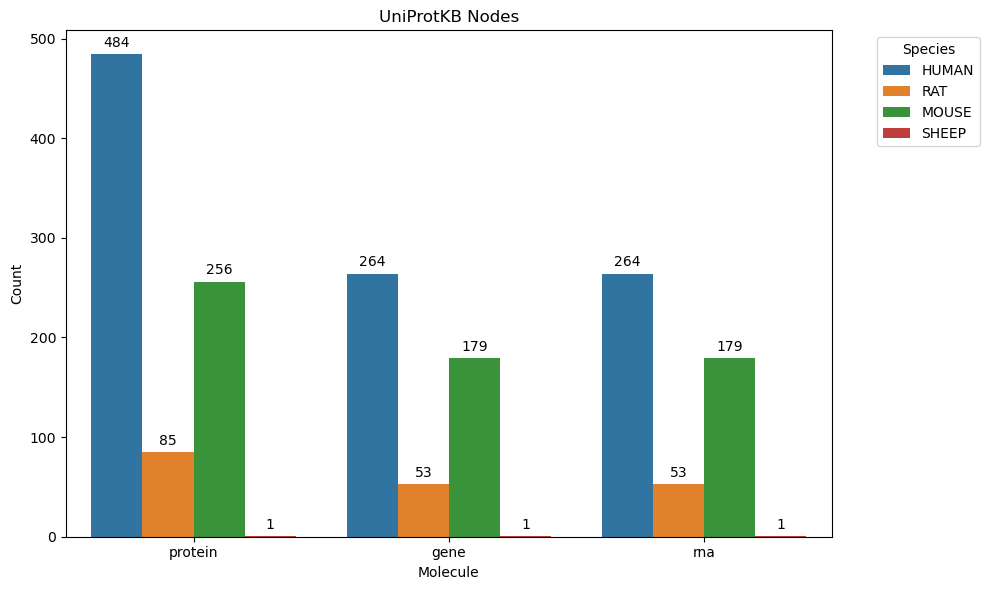

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_healthy, ax=ax, x='Molecule', y='Count', hue='Species')

# Iterate through the bar containers and add labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('UniProtKB Nodes')
plt.ylabel('Count') 
plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Extract protein nodes in AD-KG

In [11]:
hgnc = defaultdict(list)
for n, attr in ad_kg.nodes(data=True):
    #print(n)
    label = attr.get('label', None)
    #print(label)
    if attr.get('namespace', None) == 'HGNC':
        hgnc[label].append(n)
hgnc.keys()

dict_keys(['Gene', 'MicroRna', 'Protein', 'Rna'])

In [12]:
def get_hgnc_name(text, pattern:str='(HGNC:"(\w+)")'):
    match = re.search(pattern, text)
    if match:
        name = match.group(2)
        #print(name)
        return name
    else:
        return None

hgnc_names = defaultdict(list)
for k, v in hgnc.items():
    for i in v:
        name = get_hgnc_name(i)
        hgnc_names[k].append(name)


# Flattening the dictionary for Seaborn plot
hgnc_rows = []
for molecule, names in hgnc_names.items():
    hgnc_rows.append({'Molecule': molecule, 'Name': names, 'Count': len(names)})

df_ad = pd.DataFrame(hgnc_rows)
df_ad

,Molecule,Name,Count
0,Gene,"[BDNF, TP53, PPP1CC, VLDLR, SLC1A2, PTK2B, PPA...",128
1,MicroRna,"[MIR132, MIR195, MIR130A, MIR137, MIR106B, MIR...",45
2,Protein,"[GRIN2B, GRIN2D, GRIA1, GRM2, IL6, TNF, IL2, T...",1006
3,Rna,"[GSK3B, IL6, INSR, AGER, GRIA2, BACE1, IL1B, T...",86


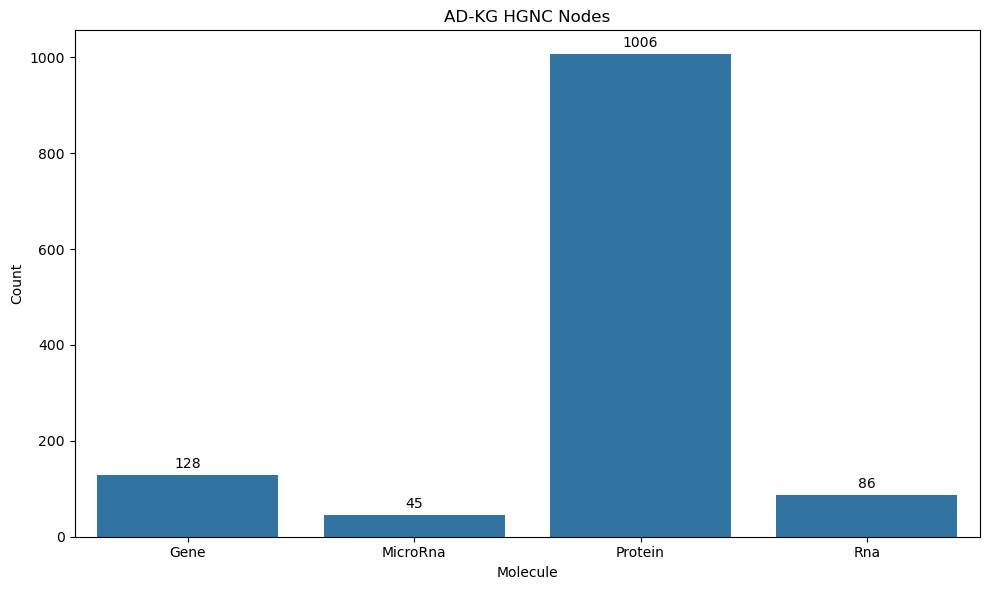

In [13]:
# barplot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_ad, ax=ax, x='Molecule', y='Count')

# Iterate through the bar containers and add labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('AD-KG HGNC Nodes')
plt.ylabel('Count') 
plt.tight_layout()
plt.show()

## Comparison of Proteins in Healthy-KG, AD-KG and GeneExpression

In [22]:
# GeneExpression proteins
exp = pd.read_csv("../Anyburl/data/adni_gene_cleaned.csv", index_col=0).T
exp_proteins = set(exp.columns)
len(exp_proteins)

19100

In [14]:
# healthy proteins 
healthy_prs = set(uniprotkb['protein']['HUMAN'])
print(len(healthy_prs))

# ad proteins
ad_prs = set(hgnc_names['Protein'])
print(len(ad_prs))

264
778


In [15]:
from matplotlib_venn import venn3, venn2
import matplotlib.patches as mpatches

def plot_venn3(set1, set2, set3, label1, label2, label3):
    plt.figure(figsize=(10,6))
    venn = venn3((set1, set2, set3), set_labels=('', '', ''))
    red_patch = mpatches.Patch(color='salmon', alpha=0.6, label=label1)
    blue_patch = mpatches.Patch(color='blue', alpha=0.6, label=label2)
    green_patch = mpatches.Patch(color='green', alpha=0.6, label=label3)

    # 2. Add the legend to the plot
    plt.legend(handles=[red_patch, blue_patch, green_patch], loc='lower right', title="Legend")
    plt.title('Proteins Overlapping Comparison')
    plt.show()

In [16]:
healthy_human_protein = uniprotkb['protein']['HUMAN']
healthy_rat_protein = uniprotkb['protein']['RAT']
healthy_mouse_protein = uniprotkb['protein']['MOUSE']
healthy_kg_protein = set(healthy_human_protein)
healthy_kg_protein.union(set(uniprotkb['protein']['MOUSE']))
healthy_kg_protein.union(set(uniprotkb['protein']['RAT']))
healthy_kg_protein.union(set(uniprotkb['protein']['SHEEP']))
print(f"Number of unique proteins in Healthy-Aging-KG: {len(healthy_kg_protein)}")

Number of unique proteins in Healthy-Aging-KG: 264


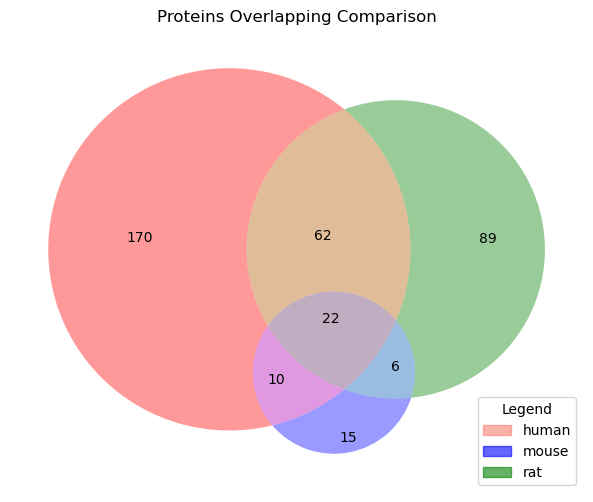

In [18]:
plot_venn3(set(healthy_human_protein), set(healthy_mouse_protein), set(healthy_rat_protein), 'human', 'mouse', 'rat')

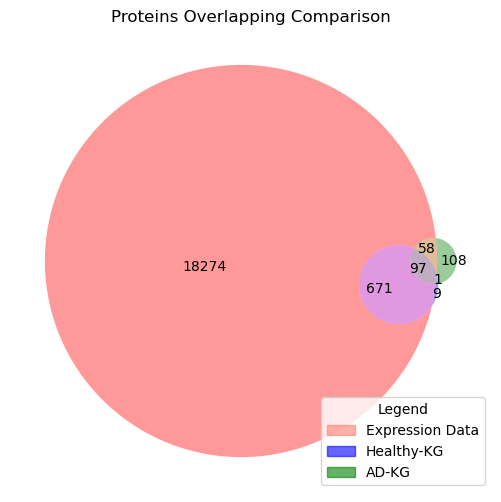

In [23]:
plt.figure(figsize=(10,6))
venn = venn3((exp_proteins, healthy_prs, ad_prs), set_labels=('', '', ''))
red_patch = mpatches.Patch(color='salmon', alpha=0.6, label='Expression Data')
blue_patch = mpatches.Patch(color='blue', alpha=0.6, label='Healthy-KG')
green_patch = mpatches.Patch(color='green', alpha=0.6, label='AD-KG')

# 2. Add the legend to the plot
plt.legend(handles=[red_patch, blue_patch, green_patch], loc='lower right', title="Legend")
plt.title('Proteins Overlapping Comparison')
plt.show()

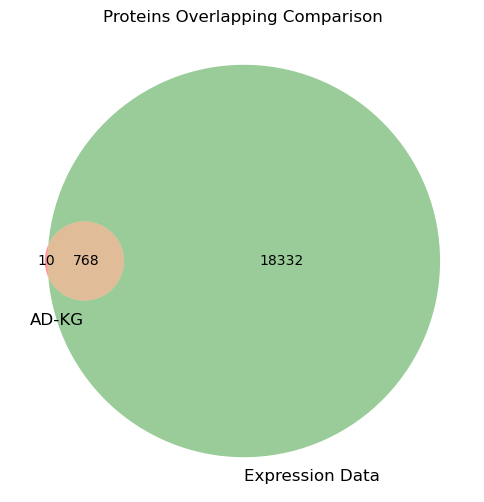

In [133]:
plt.figure(figsize=(10,6))
venn = venn2((ad_prs, exp_proteins), set_labels=('AD-KG', 'Expression Data'))
#plt.legend(handles=[red_patch, blue_patch, green_patch], loc='lower right', title="Legend")
plt.title('Proteins Overlapping Comparison')
plt.show()

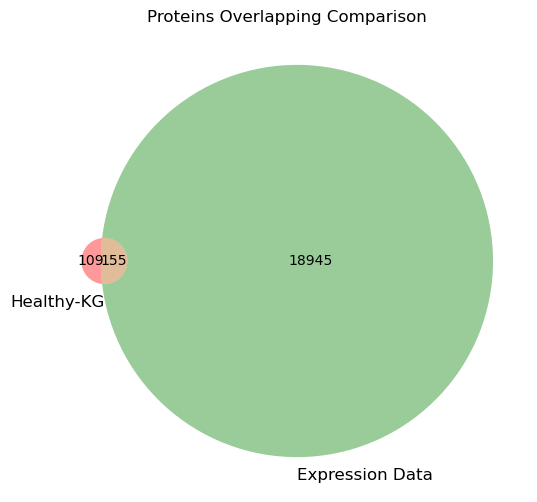

In [24]:
plt.figure(figsize=(10,6))
venn = venn2((healthy_prs, exp_proteins), set_labels=('Healthy-KG', 'Expression Data'))
#plt.legend(handles=[red_patch, blue_patch, green_patch], loc='lower right', title="Legend")
plt.title('Proteins Overlapping Comparison')
plt.show()

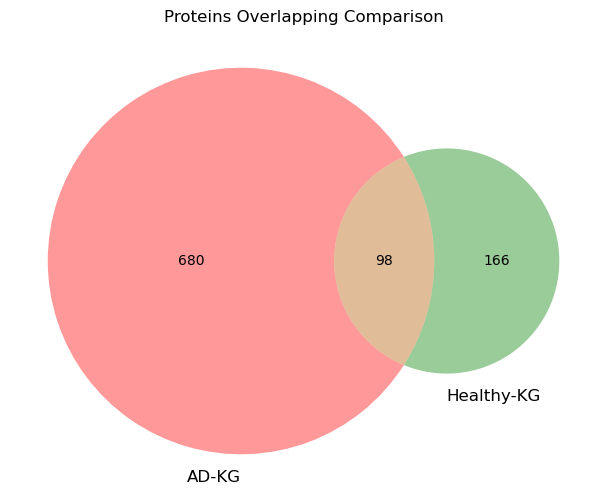

In [26]:
plt.figure(figsize=(10,6))
venn = venn2((ad_prs, healthy_kg_protein), set_labels=('AD-KG', 'Healthy-KG'))
#plt.legend(handles=[red_patch, blue_patch, green_patch], loc='lower right', title="Legend")
plt.title('Proteins Overlapping Comparison')
plt.show()

## Common Protein in AD-KG and Healthy-KG analysis

In [17]:
def get_name_species(text:str, pattern:str = r'(UniProtKB:"(\w+)_(\w+)")\)'):
    match = re.search(pattern, text)
    if match:
        #print(match.group())
        name = match.group(2)
        species = match.group(3)
        return name, species
    else:
        #print('No match found.')
        return "", ""

def get_hgnc_name(text, pattern:str=r'(HGNC:"(\w+)")\)'):
    match = re.search(pattern, text)
    if match:
        name = match.group(2)
        #print(name)
        return name
    else:
        return None


In [18]:
ad_healthy_prs = ad_prs.intersection(healthy_kg_protein)
# 1. get all the protein nodes has given protein names
healthy_pr_nodes = []
healthy_pr_node_names = []
for node, attrs in health_kg.nodes(data=True):
    label = attrs['label']
    namespace = attrs.get('namespace', None)
    node_id = attrs.get('bel', None)
    name = attrs.get('name', None)
    #print(attrs)
    if namespace == 'UniProtKB' and label == 'protein':
        #print(node)
        #print(node_id)
        #print(name)
        pr, _ = get_name_species(node_id)
        #print(pr)
        if pr in ad_healthy_prs: 
            healthy_pr_nodes.append(node)
            healthy_pr_node_names.append(node_id)
            attrs['size'] = health_kg.degree(node)

In [19]:
healthy_pr_node_names

['p(UniProtKB:"IGF1_HUMAN")',
 'p(UniProtKB:"LRP1_MOUSE")',
 'p(UniProtKB:"CLU_HUMAN")',
 'p(UniProtKB:"GAB2_HUMAN")',
 'p(UniProtKB:"CASP6_HUMAN")',
 'p(UniProtKB:"CREB1_HUMAN")',
 'p(UniProtKB:"APOE_HUMAN")',
 'p(UniProtKB:"APLP2_MOUSE")',
 'p(UniProtKB:"ABCA1_HUMAN")',
 'p(UniProtKB:"PPARA_MOUSE")',
 'p(UniProtKB:"APBA1_HUMAN")',
 'p(UniProtKB:"PPARG_MOUSE")',
 'p(UniProtKB:"LRP2_MOUSE")',
 'p(UniProtKB:"APLP1_HUMAN")',
 'p(UniProtKB:"TGFB1_RAT")',
 'p(UniProtKB:"DAB1_MOUSE")',
 'p(UniProtKB:"APLP2_HUMAN")',
 'p(UniProtKB:"UCHL1_MOUSE")',
 'p(UniProtKB:"LRP8_HUMAN")',
 'p(UniProtKB:"DLG4_HUMAN")',
 'p(UniProtKB:"IL1B_HUMAN")',
 'p(UniProtKB:"CCL3_MOUSE")',
 'p(UniProtKB:"INS_HUMAN")',
 'p(UniProtKB:"RELN_MOUSE")',
 'p(UniProtKB:"RELN_RAT")',
 'p(UniProtKB:"EGF_HUMAN")',
 'p(UniProtKB:"LRP2_HUMAN")',
 'p(UniProtKB:"LRP1_HUMAN")',
 'p(UniProtKB:"APH1A_HUMAN")',
 'p(UniProtKB:"GRB2_HUMAN")',
 'p(UniProtKB:"EFNB2_HUMAN")',
 'p(UniProtKB:"ERBB4_HUMAN")',
 'p(UniProtKB:"SRC_RAT")',
 'p(Un

In [20]:
len(healthy_pr_node_names)

163

get ad-kg protein nodes that are aslo in healthy-kg

In [21]:
ad_pr_nodes = []
for node, attrs in ad_kg.nodes(data=True):
    if node.startswith('p('):
        pr_name = get_hgnc_name(node)
        if pr_name in ad_healthy_prs:
            ad_pr_nodes.append(node)
            attrs['size'] = ad_kg.degree(node)
print(len(ad_pr_nodes))

91


In [63]:
ad_pr_nodes

['p(HGNC:"IL6")',
 'p(HGNC:"IL2")',
 'p(HGNC:"NOS2")',
 'p(HGNC:"GSK3B")',
 'p(HGNC:"AKT1")',
 'p(HGNC:"FOXO4")',
 'p(HGNC:"STK11")',
 'p(HGNC:"CREB1")',
 'p(HGNC:"PPARA")',
 'p(HGNC:"INSR")',
 'p(HGNC:"RELN")',
 'p(HGNC:"PRL")',
 'p(HGNC:"STAT3")',
 'p(HGNC:"INS")',
 'p(HGNC:"GRB2")',
 'p(HGNC:"BACE1")',
 'p(HGNC:"EGFR")',
 'p(HGNC:"SRC")',
 'p(HGNC:"PPARG")',
 'p(HGNC:"LRP8")',
 'p(HGNC:"LEP")',
 'p(HGNC:"NFKB1")',
 'p(HGNC:"EGF")',
 'p(HGNC:"ABCA1")',
 'p(HGNC:"IRS1")',
 'p(HGNC:"CR1")',
 'p(HGNC:"IDE")',
 'p(HGNC:"DLG4")',
 'p(HGNC:"IL1B")',
 'p(HGNC:"CCL3")',
 'p(HGNC:"IFNG")',
 'p(HGNC:"CCL2")',
 'p(HGNC:"TGFB1")',
 'p(HGNC:"IL1A")',
 'p(HGNC:"FOXO3")',
 'p(HGNC:"FOXO1")',
 'p(HGNC:"BCL2")',
 'p(HGNC:"IGF1")',
 'p(HGNC:"GSK3A")',
 'p(HGNC:"FOS")',
 'p(HGNC:"VLDLR")',
 'p(HGNC:"JUN")',
 'p(HGNC:"CASP3")',
 'p(HGNC:"GFAP")',
 'p(HGNC:"BAD")',
 'p(HGNC:"CCR2")',
 'p(HGNC:"APOE")',
 'p(HGNC:"APH1A")',
 'p(HGNC:"CDK5")',
 'p(HGNC:"CLU")',
 'p(HGNC:"APBB1")',
 'p(HGNC:"APLP1")',
 'p(HG

In [22]:
# 2. extract subgraphs containing only intersected proteins
subgraph_ad = ad_kg.subgraph(ad_pr_nodes)
subgraph_healthy = health_kg.subgraph(healthy_pr_nodes)

In [54]:
# rename the node ids fro the healthy kg
mapping = {}
for node, data in subgraph_healthy.nodes(data=True):
    new_name = data.get('bel')
    mapping[node] = new_name
subgraph_health = nx.relabel_nodes(subgraph_healthy, mapping, copy=True)

# rename relations
new_graph = nx.MultiDiGraph()

# 2. Add nodes with their existing data
new_graph.add_nodes_from(subgraph_health.nodes(data=True))

# 3. Add edges using the 'type' as the new key
for u, v, old_key, data in subgraph_health.edges(data=True, keys=True):
    # Get the relationship name (e.g., 'decreases')
    new_key = data.get('type') 
    #print(new_key)
    #break
    
    # Add the edge to the new graph
    new_graph.add_edge(u, v, new_key, **data)

In [50]:
def get_triples(subgraph):
    triples = []
    for u, v, rel, data in subgraph.edges(data=True, keys=True):
        
        triples.append((u, rel, v))
    return triples

In [55]:
ad_triples = get_triples(subgraph_ad)
healthy_triples = get_triples(new_graph)
ad_triples

[('p(HGNC:"APOE")', 'increases', 'p(HGNC:"LRP1B")'),
 ('p(HGNC:"IFNG")', 'increases', 'p(HGNC:"IL1B")'),
 ('p(HGNC:"IL1B")', 'increases', 'p(HGNC:"CLU")'),
 ('p(HGNC:"IL1B")', 'increases', 'p(HGNC:"APOE")'),
 ('p(HGNC:"IL1B")', 'increases', 'p(HGNC:"NFKB1")'),
 ('p(HGNC:"IL1B")', 'increases', 'p(HGNC:"CCL2")'),
 ('p(HGNC:"LDLR")', 'regulates', 'p(HGNC:"APOE")'),
 ('p(HGNC:"NFKB1")', 'decreases', 'p(HGNC:"BACE1")'),
 ('p(HGNC:"NFKB1")', 'increases', 'p(HGNC:"BACE1")'),
 ('p(HGNC:"NFKB1")', 'increases', 'p(HGNC:"IL1B")'),
 ('p(HGNC:"NFKB1")', 'increases', 'p(HGNC:"CCL3")'),
 ('p(HGNC:"LEP")', 'decreases', 'p(HGNC:"GSK3B")'),
 ('p(HGNC:"LEP")', 'decreases', 'p(HGNC:"BACE1")'),
 ('p(HGNC:"NOS2")', 'decreases', 'p(HGNC:"IDE")'),
 ('p(HGNC:"FOXO3")', 'decreases', 'p(HGNC:"IGF1")'),
 ('p(HGNC:"PPARG")', 'decreases', 'p(HGNC:"IL6")'),
 ('p(HGNC:"PPARG")', 'increases', 'p(HGNC:"IL6")'),
 ('p(HGNC:"PPARG")', 'decreases', 'p(HGNC:"NOS2")'),
 ('p(HGNC:"PPARG")', 'regulates', 'p(HGNC:"NOS2")'),
 ('

In [56]:
healthy_triples

[('p(UniProtKB:"NR1H2_HUMAN")', 'decreases', 'p(UniProtKB:"VLDLR_HUMAN")'),
 ('p(UniProtKB:"MYLIP_HUMAN")', 'decreases', 'p(UniProtKB:"LDLR_HUMAN")'),
 ('p(UniProtKB:"MYLIP_HUMAN")', 'decreases', 'p(UniProtKB:"VLDLR_HUMAN")'),
 ('p(UniProtKB:"MYLIP_HUMAN")', 'decreases', 'p(UniProtKB:"LRP8_HUMAN")'),
 ('p(UniProtKB:"PPARA_MOUSE")', 'increases', 'p(UniProtKB:"LRP2_MOUSE")'),
 ('p(UniProtKB:"MYLIP_MOUSE")', 'decreases', 'p(UniProtKB:"LDLR_MOUSE")'),
 ('p(UniProtKB:"MYLIP_MOUSE")', 'decreases', 'p(UniProtKB:"VLDLR_MOUSE")'),
 ('p(UniProtKB:"MYLIP_MOUSE")', 'decreases', 'p(UniProtKB:"LRP8_MOUSE")'),
 ('p(UniProtKB:"NR1H3_HUMAN")', 'decreases', 'p(UniProtKB:"VLDLR_HUMAN")'),
 ('p(UniProtKB:"PPARA_RAT")', 'increases', 'p(UniProtKB:"LRP2_RAT")'),
 ('p(UniProtKB:"UCHL1_MOUSE")', 'decreases', 'p(UniProtKB:"BACE1_MOUSE")'),
 ('p(UniProtKB:"UCHL1_MOUSE")', 'regulates', 'p(UniProtKB:"BACE1_MOUSE")'),
 ('p(UniProtKB:"NR1H2_MOUSE")', 'decreases', 'p(UniProtKB:"VLDLR_MOUSE")'),
 ('p(UniProtKB:"LRP1_M

In [58]:
for u, r, v in ad_triples:
    u_pr = get_hgnc_name(u)
    v_pr = get_hgnc_name(v)
    print(u_pr, r, v_pr)

APOE increases LRP1B
IFNG increases IL1B
IL1B increases CLU
IL1B increases APOE
IL1B increases NFKB1
IL1B increases CCL2
LDLR regulates APOE
NFKB1 decreases BACE1
NFKB1 increases BACE1
NFKB1 increases IL1B
NFKB1 increases CCL3
LEP decreases GSK3B
LEP decreases BACE1
NOS2 decreases IDE
FOXO3 decreases IGF1
PPARG decreases IL6
PPARG increases IL6
PPARG decreases NOS2
PPARG regulates NOS2
PPARG directly_decreases BACE1
GGA3 decreases BACE1
INS decreases IDE
LRP2 increases CLU
NR1H3 regulates MYLIP
NR1H2 regulates MYLIP
IL1A increases NFKB1
TGFB1 increases CLU


In [59]:
for u, r, v in healthy_triples:
    u_pr,_ = get_name_species(u)
    v_pr,_ = get_name_species(v)
    print(u_pr, r, v_pr)

NR1H2 decreases VLDLR
MYLIP decreases LDLR
MYLIP decreases VLDLR
MYLIP decreases LRP8
PPARA increases LRP2
MYLIP decreases LDLR
MYLIP decreases VLDLR
MYLIP decreases LRP8
NR1H3 decreases VLDLR
PPARA increases LRP2
UCHL1 decreases BACE1
UCHL1 regulates BACE1
NR1H2 decreases VLDLR
LRP1 decreases APOE
LRP1 regulates APOE
ABCA1 increases APOE
CLU increases LRP2


In [ ]:
all_paths = []
for node in subgraph_ad.nodes():
    # Find all paths starting at 'node' with a specific cutoff
    # target=None finds all possible protein targets in your list
    paths = nx.all_simple_paths(subgraph_ad, source=node, target=None, cutoff=2)
    all_paths.extend(list(paths))